---   
 <img align="left" width="75" height="75"  src="https://upload.wikimedia.org/wikipedia/en/c/c8/University_of_the_Punjab_logo.png">

<h1 align="center">Department of Data Science</h1>
<h1 align="center">Course: Generative and Agentic AI</h1>

---
<h3><div align="right">Instructor: Muhammad Arif Butt, Ph.D.</div></h3>    

<br><br>
<h1 align="center">Lec-25: Fine-Tuning TinyLlama using <b>TRL</b></h1>

# Learning Agenda of This Notebook

1. Install Dependencies and Check your Runtime (only in Google Colab)
2. Dataset Curation
3. Configuration of Model, Dataset, LoRA Adapters, and Training Hyperparameters
4. Load Base Model + Tokenizer
5. Prepare Dataset
6. Configure and Inject LoRA Adapters
7. Configure Training Parameters
8. Train the Model (only on Google Colab)
9. Training Loss Plot
10. Save the Adapter Weights, Push to HF and Do Inference (`arif-butt/tinyllama-trl-lora-adapter`)
11. Merge Adapter Weights, Push to HF and Do Inference (`arif-butt/tinyllama-trl-merged`)
12. Generate GGUF and Push to to HF and Do Inverence via Ollama and Llama.cpp (`arif-butt/tinyllama-trl-gguf`)

# <span style='background :lightgreen' >1. Install Dependencies and Check your Runtime (If in Google Colab)</span>
```
`transformers` | Load pretrained models and tokenizers from HuggingFace
`peft`         | Provides `LoraConfig` and `get_peft_model()` for LoRA adapter injection
`datasets`     | Load datasets from HuggingFace Hub
`accelerate`   | Enables efficient GPU training
`trl`          | Training utilities
```

In [1]:
import warnings
warnings.filterwarnings('ignore')

!pip uninstall -y bitsandbytes 2>/dev/null || true
!pip uninstall -y trl 2>/dev/null || true

!pip install -q -U \
    transformers==4.41.0 \
    peft==0.11.1 \
    datasets \
    accelerate==0.30.1 \
    huggingface_hub \
    trl==0.9.6 \
    scipy \

print("All packages installed successfully!")

Found existing installation: trl 0.9.6
Uninstalling trl-0.9.6:
  Successfully uninstalled trl-0.9.6
All packages installed successfully!


In [1]:
# For the training part of this notebook, you need a GPU, rest you can run on your laptop
# If in Colab, Go to `Runtime > Change runtime type > T4 GPU`
import torch

if torch.cuda.is_available():
    print(f"GPU  : {torch.cuda.get_device_name(0)}")
    print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No CUDA GPU detected. Running on CPU.")

No CUDA GPU detected. Running on CPU.


# <span style='background :lightgreen' >2. Dataset Curation</span>
- The dataset used for fine-tuning is a **custom synthetic Q&A dataset** built around **Dr. Muhammad Arif Butt** — covering his academic background, teaching experience, research interests, contact information and YouTube channel — curated specifically to teach the model to answer questions about him accurately and naturally.
## How the Dataset Was Curated
The dataset was created following a six-step curation pipeline — the same pipeline students can follow to build their own domain-specific datasets:
- **Step 1 — Collection:** Raw facts were gathered from Dr. Arif Butt's official website (https://arifbutt.me) and YouTube channel — covering all relevant topics including academic position, qualifications, research interests, courses taught and contact details
- **Step 2 — AI-Assisted Q&A Generation:** Each collected fact was fed into an AI model with a prompt instructing it to generate **3 to 5 different question variations per fact** — this rephrasing improves model generalisation by teaching it to answer the same fact regardless of how the question is phrased:
```
Fact: "Dr. Arif Butt is an Assistant Professor at PUCIT"

Generated question variations:
  "Who is Dr. Muhammad Arif Butt?"
  "Tell me about Dr. Arif Butt"
  "What is Arif Butt's current position?"
  "Where does Dr. Muhammad Arif Butt work?"
  "Which university does Dr. Arif Butt teach at?"
```
- **Step 3 — Cleaning and Validation:** All generated Q&A pairs were reviewed to remove duplicates, fix factual inaccuracies, ensure consistent tone and style, and discard any incomplete or low quality examples — human review of every example is critical at this stage since AI-generated data can contain subtle errors
- **Step 4 — Formatting:** Each Q&A pair was structured into the **ChatML messages format** required by TinyLlama — this is not optional — the model was pre-trained on this exact format and will only respond correctly if fine-tuning data matches it:
```json
{
  "messages": [
    {"role": "user",      "content": "Who is Dr. Muhammad Arif Butt?"},
    {"role": "assistant", "content": "Dr. Muhammad Arif Butt is an Assistant Professor
                                      at the Department of Data Science,
                                      University of the Punjab..."}
  ]
}
```
- **Step 5 — Balancing:** Questions were distributed evenly across all topics — academic background, teaching experience, research interests, contact information and YouTube channel — preventing the model from becoming biased toward one topic while forgetting others
- **Step 6 — Upload to HuggingFace Hub:** The final cleaned and formatted dataset was saved as `.jsonl` and uploaded as a public dataset so it can be loaded in one line anywhere:

#### 🔗 **Dataset:** [arif-butt/arifbutt_dataset](https://huggingface.co/datasets/arif-butt/arifbutt_dataset)


## Students should build their own synthetic Dataset
- Pick any domain, a product, a company or a public figure.
- Collect facts from public sources;  websites, Wikipedia, official pages.
- Feed the facts into an AI model and ask it to generate 3 to 5 question variations per fact.
- Review and clean all generated pairs, remove duplicates and fix any inaccuracies.
- Format each pair as ChatML `messages` and save as `.jsonl`.
- Upload to HuggingFace Hub using `dataset.push_to_hub()` and your dataset is ready to use.

# <span style='background :lightgreen' >3. Configuration of Model, Dataset, LoRA Adapters, and Training Hyperparameters</span>
- The code cell below defines the base model, dataset source, output directories, LoRA configuration, and training hyperparameters required for fine-tuning.
- It centralizes all experiment settings such as batch size, learning rate, and sequence length to make the training pipeline easy to configure and reproduce.
- Finally, it creates the required output directories for saving LoRA adapters and the merged final model.

In [2]:
import torch
import gc
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, TaskType, PeftModel
from trl import SFTTrainer, SFTConfig
from datasets import load_dataset

# ── Model & Data ───────────────────────────────────────────────
BASE_MODEL_ID   = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"          # Base model to fine-tune (1.1B parameters)
HF_DATASET_NAME = "arif-butt/tinyllama-merged-arifbutt"         # Dataset on HuggingFace Hub for training
ADAPTER_OUTPUT_DIR      = "./tinyllama-trl-lora-adapter"         # Where to save just the LoRA adapter weights (few MB)
MERGED_OUTPUT_DIR  = "./tinyllama-trl-merged"                   # Where to save merged model (base + LoRA combined) for inference

SYSTEM_PROMPT = (
    "You are a helpful assistant."                               # System instruction prepended to every training example
)

# ── LoRA Hyperparameters ───────────────────────────────────────
LORA_R       = 16      # adapter rank (higher = more capacity, more memory)
LORA_ALPHA   = 32      # scaling factor = alpha / r = 2.0 (controls LoRA contribution strength)
LORA_DROPOUT = 0.05    # regularization dropout (prevents overfitting, 0 = no dropout)

# ── Training Hyperparameters ───────────────────────────────────
NUM_EPOCHS     = 3      # Number of full passes through the dataset
BATCH_SIZE     = 1      # Samples per GPU (small due to model size, gradient accumulation compensates)
GRAD_ACCUM     = 2      # Accumulate gradients over 2 steps (effective batch size = 1 * 2 = 2)
LEARNING_RATE  = 2e-4   # Learning rate for optimizer (higher than full fine-tuning due to LoRA)
MAX_SEQ_LENGTH = 128    # Maximum tokens per example (truncates longer sequences)
warmup_step    = 10     # Number of steps for learning rate warmup
SAVE_STEPS     = 50     # Save checkpoint every N steps
LOGGING_STEPS  = 10     # Log metrics every N steps
SEED           = 42     # Random seed for reproducibility

print("Config ready!")

Config ready!


# <span style='background :lightgreen' >4. Load Base Model + Tokenizer</span>

In [3]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

print("Loading TinyLlama base model...")
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    torch_dtype=torch.float32,    # Full precision → maximum accuracy
    device_map="auto",            # auto-place layers on GPU
    trust_remote_code=True,
)
model.config.use_cache = False    # required during training

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    BASE_MODEL_ID,
    trust_remote_code=True,
)
tokenizer.pad_token    = tokenizer.eos_token    # no dedicated pad token
tokenizer.padding_side = "right"                # right-pad for causal LM

print("Model + Tokenizer ready!")
print(f"Vocab size  : {tokenizer.vocab_size:,}")
print(f"Model dtype : {next(model.parameters()).dtype}")

Loading TinyLlama base model...


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loading tokenizer...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Model + Tokenizer ready!
Vocab size  : 32,000
Model dtype : torch.float32


# <span style='background :lightgreen' >5. Prepare Dataset</span>

In [4]:
from datasets import load_dataset
from dotenv import load_dotenv      # Imports the load_dotenv function, which loads environment variables from a .env file into your Python environment.
from huggingface_hub import login   # Imports the login() function that allows you to authenticate with the Hugging Face Hub using an access token.
import os                           # Imports Python’s built-in os module so you can access environment variables (like your HF token).

# The following login() call is only necessary if you want to access private repos, or to use private models or to push models/datasets
'''
load_dotenv('../keys/.env', override=True)
hf_token = os.getenv('HF_TOKEN')
login(token=hf_token)
'''

raw_dataset = load_dataset("arif-butt/arifbutt_dataset")
print("✓ Dataset loaded successfully!")
raw_dataset

drarif.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1926 [00:00<?, ? examples/s]

✓ Dataset loaded successfully!


DatasetDict({
    train: Dataset({
        features: ['messages'],
        num_rows: 1926
    })
})

In [5]:
print("\nSample examples from the training split:\n")
for idx in range(5):
    sample = raw_dataset["train"][idx]
    print(f"Example {idx + 1}: {sample}")


Sample examples from the training split:

Example 1: {'messages': [{'role': 'user', 'content': 'Who is Dr. Muhammad Arif Butt?'}, {'role': 'assistant', 'content': 'Dr. Muhammad Arif Butt is an accomplished Assistant Professor at the Department of Data Science, University of the Punjab (PU), Lahore, Pakistan. He has over 33 years of experience in teaching and management, with expertise in cybersecurity, operating systems, and artificial intelligence.'}]}
Example 2: {'messages': [{'role': 'user', 'content': 'Tell me about Dr. Arif Butt'}, {'role': 'assistant', 'content': "Dr. Muhammad Arif Butt is an Assistant Professor at Punjab University's Data Science department. He's a technology entrepreneur and cybersecurity expert with 33+ years of experience, combining academic excellence with industry innovation."}]}
Example 3: {'messages': [{'role': 'user', 'content': "What is Arif butt's current position?"}, {'role': 'assistant', 'content': 'Dr. Muhammad Arif Butt currently serves as an Assi

## Format the [arif-butt/arifbutt_dataset](https://huggingface.co/datasets/arif-butt/arifbutt_dataset)
- The dataset uses a `messages` format — a list of `{role, content}` dicts. We must convert each example into the exact ChatML string format TinyLlama expects:

```
<|system|>
You are a helpful assistant.</s>
<|user|>
Who is Dr. Arif Butt?</s>
<|assistant|>
Dr. Muhammad Arif Butt is an Assistant Professor...</s>
```

**Steps inside `format_example()`:**
1. Detects dataset layout (messages / instruction+output / plain text)
2. Builds the correct ChatML string for each example
3. `dataset.map()` applies this to every example in the dataset

**Tokenization:**
- `labels = input_ids` — for causal LM, the model learns to predict the next token, so labels are the same as inputs
- `truncation=True` — examples longer than `MAX_SEQ_LENGTH` are cut off
- `padding="max_length"` — shorter examples are padded to the same length

In [6]:
################# CONVERT DATASET ROWS INTO TINYLLAMA CHAT FORMAT ###############################

# ── Format Function ───────────────────────────────────────────────────────────
def format_example(example):
    """Format messages into TinyLlama ChatML conversation."""
    text = "<|system|>\nYou are a helpful assistant.</s>\n"  # start every conversation with a system prompt that sets the assistant's behaviour and persona
    for msg in example["messages"]:         # iterate over each message in the conversation — each message is a dict with "role" and "content" keys
        role    = msg["role"]               # extract the role of the message sender — either "user" or "assistant"
        content = msg["content"].strip()    # extract and clean the message text — strip() removes any leading or trailing whitespace
        if role == "user":
            text += f"<|user|>\n{content}</s>\n"        # wrap user message in TinyLlama's ChatML user tags — <|user|> opens and </s> closes the turn
        elif role == "assistant":
            text += f"<|assistant|>\n{content}</s>\n"   # wrap assistant message in TinyLlama's ChatML assistant tags — model learns to generate text between these tags
    return {"formatted_text": text}   # return the fully formatted conversation as a new column called "formatted_text" that replaces the original "messages" column

# ── Tokenize Function ─────────────────────────────────────────────────────────
def tokenize(example):
    """Convert formatted text into token IDs."""
    result = tokenizer(
                    example["formatted_text"],      # pass the ChatML formatted conversation string to the tokenizer for conversion to token IDs
                    truncation=True,                # if the formatted text exceeds MAX_SEQ_LENGTH tokens — cut it off and keep only the first MAX_SEQ_LENGTH tokens
                    max_length=MAX_SEQ_LENGTH,      # set the fixed sequence length to 512 — all sequences will be either truncated or padded to exactly this length
                    padding="max_length",           # if the formatted text is shorter than MAX_SEQ_LENGTH — pad it on the right with the pad token (EOS token) to reach exactly 512 tokens
                )
    result["labels"] = result["input_ids"].copy()   # for causal language model training the labels are identical to input_ids — the model learns to predict the next token by shifting input one position right internally
    return result   # return tokenized output containing input_ids, attention_mask and labels — all of length MAX_SEQ_LENGTH

# ── Apply Formatting ──────────────────────────────────────────────────────────
formatted_dataset = raw_dataset.map(
                        format_example,                                    # apply the format_example function to every row in the dataset
                        remove_columns=raw_dataset["train"].column_names,  # drop all original columns (messages, etc.) and keep only the new "formatted_text" column
                        )

# ── Tokenize Dataset ──────────────────────────────────────────────────────────
tokenized_dataset = formatted_dataset.map(
                        tokenize,                          # apply the tokenize function to every row in the formatted dataset
                        batched=True,                      # process multiple examples at once for significantly faster tokenization
                        remove_columns=["formatted_text"], # drop the "formatted_text" string column — no longer needed after tokenization
                        )

# ── Train / Eval Split ────────────────────────────────────────────────────────
spl = tokenized_dataset["train"].train_test_split(test_size=0.1, seed=SEED)  # randomly split the tokenized training data into 90% train and 10% evaluation using fixed seed for reproducibility

train_dataset = spl["train"]  # assign the 90% split to train_dataset — used to update LoRA adapter weights during training
eval_dataset  = spl["test"]   # assign the 10% split to eval_dataset  — used to monitor loss on unseen examples during training without updating any weights

print("Dataset prepared")
print(f"Train examples:\n {train_dataset}")  # print the train dataset object showing number of examples, column names and data types
print(f"Eval examples:\n {eval_dataset}")    # print the eval  dataset object showing number of examples, column names and data types

Map:   0%|          | 0/1926 [00:00<?, ? examples/s]

Map:   0%|          | 0/1926 [00:00<?, ? examples/s]

Dataset prepared
Train examples:
 Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 1733
})
Eval examples:
 Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 193
})


In [7]:
# Print fully tokenized training example that will be fed to the model during fine-tuning of TinyLlama-1.1B-Chat-v1.0.
print(train_dataset[0])

{'input_ids': [1, 529, 29989, 5205, 29989, 29958, 13, 3492, 526, 263, 8444, 20255, 29889, 2, 29871, 13, 29966, 29989, 1792, 29989, 29958, 13, 25125, 4942, 29889, 826, 361, 505, 263, 6189, 29257, 3236, 373, 670, 14711, 8242, 29973, 2, 29871, 13, 29966, 29989, 465, 22137, 29989, 29958, 13, 8241, 29892, 4942, 29889, 29610, 826, 361, 1205, 29873, 29915, 29879, 14711, 8242, 525, 29931, 799, 29876, 2973, 826, 361, 29915, 756, 263, 6189, 29257, 3236, 411, 29871, 29945, 19707, 3625, 363, 8041, 29889, 2, 29871, 13, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [8]:
sample = train_dataset[0]
print("Decoded text:\n")
print(tokenizer.decode(sample["input_ids"]))

Decoded text:

<s> <|system|>
You are a helpful assistant.</s> 
<|user|>
Does Dr. Arif have a Machine Learning course on his YouTube channel?</s> 
<|assistant|>
Yes, Dr. Muhammad Arif Butt's YouTube channel 'Learn With Arif' has a Machine Learning course with 5 videos available for students.</s> 
</s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s></s>


# <span style='background :lightgreen' >6. Configure and Inject LoRA Adapters</span>

In [9]:
lora_config = LoraConfig(
    r=LORA_R,                     # adapter rank (16)
    lora_alpha=LORA_ALPHA,        # scaling factor (32)
    lora_dropout=LORA_DROPOUT,    # dropout (0.05)
    bias="none",                  # do not adapt bias terms
    task_type=TaskType.CAUSAL_LM,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",    # attention layers
        "gate_proj", "up_proj", "down_proj",        # MLP layers
    ],
)
# WHY SOMETIMES WE DON'T USE get_peft_model IN TRL:
# - TRL's SFTTrainer has built-in LoRA support via peft_config parameter
# - When using SFTTrainer with peft_config, it automatically calls get_peft_model internally
# - This means we don't need to manually wrap the model before passing to trainer

print("LoRA config ready!")
print(f"Rank (r)        : {LORA_R}")
print(f"Alpha           : {LORA_ALPHA}")
print(f"Effective scale : {LORA_ALPHA / LORA_R}")
print(f"Target modules  : {lora_config.target_modules}")

LoRA config ready!
Rank (r)        : 16
Alpha           : 32
Effective scale : 2.0
Target modules  : {'o_proj', 'v_proj', 'up_proj', 'down_proj', 'gate_proj', 'q_proj', 'k_proj'}


# <span style='background :lightgreen' >7. Configure Training Parameters</span>

`SFTConfig` sets all training hyperparameters and passes them to `SFTTrainer`.

| Setting | Value | Explanation |
|---|---|---|
| `per_device_train_batch_size` | 4 | Samples processed per GPU per step |
| `gradient_accumulation_steps` | 4 | Gradients accumulate over 4 steps before update → effective batch = 16 |
| `fp16` | True | Half-precision training → ~2× memory saving |
| `lr_scheduler_type` | cosine | Learning rate warms up then decays smoothly along a cosine curve |
| `warmup_ratio` | 0.03 | First 3% of steps use linear warmup to avoid large early updates |
| `save_total_limit` | 2 | Keep only the 2 most recent checkpoints to save disk space |
| `dataset_text_field` | "text" | Must match the column name in our formatted dataset |

In [16]:
training_args = SFTConfig(
    output_dir=ADAPTER_OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    warmup_steps=warmup_step,
    lr_scheduler_type="cosine",
    fp16=True,
    bf16=False,
    logging_steps=LOGGING_STEPS,
    eval_strategy="steps",
    eval_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    save_strategy="steps",
    save_steps=SAVE_STEPS,
    save_total_limit=2,
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_text_field="text",
    seed=SEED,
    report_to="none", # Add this line to disable wandb logging
)

print("Training config ready!")
print(f"Epochs               : {NUM_EPOCHS}")
print(f"Effective batch size : {BATCH_SIZE * GRAD_ACCUM}")
print(f"Learning rate        : {LEARNING_RATE}")
print(f"Max sequence length  : {MAX_SEQ_LENGTH} tokens")

Training config ready!
Epochs               : 3
Effective batch size : 2
Learning rate        : 0.0002
Max sequence length  : 128 tokens


# <span style='background :lightgreen' >8. Train the Model (only on Google Colab)</span>
**What happens inside `trainer.train()`:**
```
For each batch:
  1. Forward pass   — feed tokens through model, get predictions
  2. Loss           — measure how wrong predictions are (cross-entropy)
  3. Backprop       — calculate gradients
  4. Update         — adjust only LoRA adapter weights
  5. Repeat
```

**How to read the training table:**
```
`Step`            | How many batches have been processed
`Training Loss`   | Loss on training data — should go down
`Validation Loss` | Loss on unseen data — should follow training loss
```
**Diagnosing your training:**
-  Both losses going down together → healthy training
-  Train loss low, eval loss rising → overfitting → reduce epochs
-  Both losses staying high → underfitting → increase epochs or LORA_R

**The estimated time to run this code cell on a Google Colab T4 GPU is approximately 25 minutes.You can see total steps, Train loss and Runtime in the output of this cell**

In [ ]:
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    peft_config=lora_config,      # SFTTrainer injects LoRA automatically
    args=training_args,
)

print("Training started...")
trainer.train()
print("Training complete!")

# <span style='background :lightgreen' >9. Training Loss Plot</span>
This cell plots the training and evaluation loss as a line chart so you can visually diagnose training health.

- 🔵 **Blue line** — Training loss
- 🔴 **Red dashed line** — Evaluation loss

Both lines going down smoothly and staying close together = healthy training. The plot is also saved as `training_loss.png`.

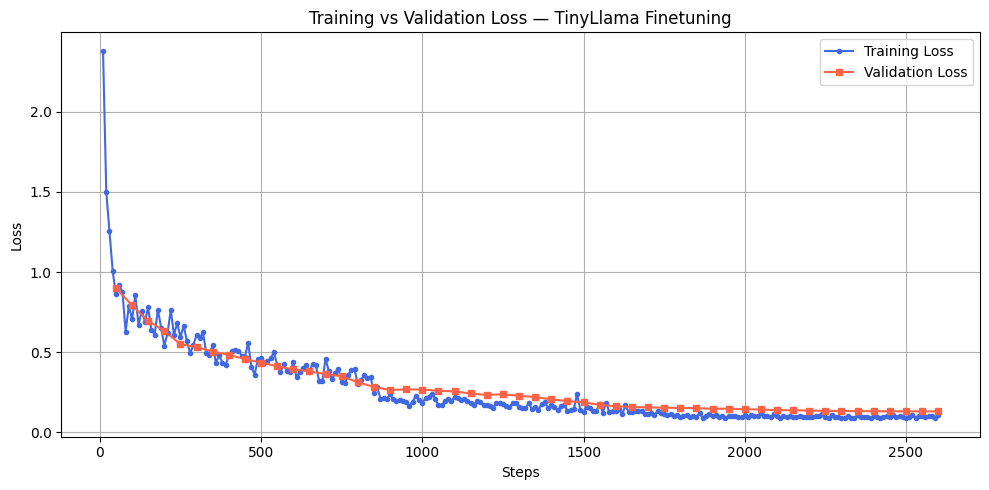

Graph saved → loss_curve.png


In [ ]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history

train_loss = [(x['step'], x['loss'])      for x in logs if 'loss' in x and 'eval_loss' not in x]
eval_loss  = [(x['step'], x['eval_loss']) for x in logs if 'eval_loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(*zip(*train_loss), label='Training Loss',   color='royalblue', marker='o', markersize=3)
plt.plot(*zip(*eval_loss),  label='Validation Loss', color='tomato',    marker='s', markersize=4)
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss — TinyLlama Finetuning')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()
print("Graph saved → loss_curve.png")

# <span style='background :lightgreen' >10. Save the Adapter Weights, Push to HF and Do Inference</span>

## a. Save the Adapter Weights
- After training we save **only the LoRA adapter weights** (48.16 MB), not the full merged model weights which will be greater than 2.2 GB.
- The saved folder contains:
    - `adapter_config.json`       — LoRA architecture definition
    - `adapter_model.safetensors` — the actual trained weights around 30 MB only
    - `tokenizer files`           — if tokenizer saved alongside adapters
- Can be pushed on hugging face hub
- The advantages of this option are:
    -  The size of files to be saved is small
    -  If pushed on HF hub, any one having TinyLlama base can download the adapter weights and use them with base model

####  After `model.save_pretrained()` and `tokenizer.save_pretrained()`, the ADAPTER_OUTPUT_DIR (`./tinyllama-peft-lora-adapters`) contains:

| File | Size | Contents |
|---|---|---|
| `adapter_model.safetensors` | 48.16 MB | The **LoRA adapter weights only** — the small delta matrices (A & B) injected into the base model layers. Does **not** contain base model weights. |
| `adapter_config.json` | 737 B | LoRA configuration: rank (`r`), alpha, dropout, target modules, task type. Needed to reconstruct the PEFT model. |
| `tokenizer.json` | 1.76 MB | Fast tokenizer data — full vocabulary, BPE merge rules, and special token mappings. |
| `tokenizer_config.json` | 1.3 KB | Tokenizer metadata — class name, special tokens (`bos_token`, `eos_token`, `pad_token`), padding side, etc. |
| `tokenizer.model` | 488.0 KB | The raw SentencePiece model file used by the slow tokenizer for subword tokenization. |
| `special_tokens_map.json` | 437 B | Maps special token names (`bos_token`, `eos_token`, `unk_token`) to their string values. |
| `checkpoint-350/` | 4.0 KB | Mid-training checkpoint saved automatically at step 350. |
| `checkpoint-400/` | 4.0 KB | Mid-training checkpoint saved automatically at step 400 (latest). |
| `README.md` | 5.0 KB | Auto-generated model card describing the adapter. |



>- **Limitation of this option is, the uploaded adapter weights cannot be used as a standalone model, for which you have to merge**

In [ ]:
# Save the trained LoRA adapter weights and configuration
trainer.save_model(ADAPTER_OUTPUT_DIR)             # LoRA adapter weights + adapter config

# Save the tokenizer files alongside the adapter for easy loading later
tokenizer.save_pretrained(ADAPTER_OUTPUT_DIR)       # Tokenizer files alongside the adapter
# Saves: tokenizer.json, tokenizer_config.json, special_tokens_map.json, etc.
# Required because tokenizer must match the base model's vocabulary

print(f"LoRA adapter saved → {ADAPTER_OUTPUT_DIR}")


LoRA adapter saved → ./tinyllama-lora-adapter


In [ ]:
import os

print(f"Files saved in {ADAPTER_OUTPUT_DIR}:\n")
for file in sorted(os.listdir(ADAPTER_OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(ADAPTER_OUTPUT_DIR, file))
    print(f"  {file:40s} {size / 1e6:.2f} MB")

Files saved in ./tinyllama-lora-adapter:

  README.md                                0.00 MB
  adapter_config.json                      0.00 MB
  adapter_model.safetensors                50.50 MB
  chat_template.jinja                      0.00 MB
  checkpoint-2600                          0.00 MB
  checkpoint-2601                          0.00 MB
  tokenizer.json                           3.62 MB
  tokenizer_config.json                    0.00 MB
  training_args.bin                        0.01 MB


## b. Push the Files to HuggingFace Hub
After merging, push the standalone model to HuggingFace Hub so it can be loaded from anywhere without needing local files.

**Before pushing, you need a Write token:**  
Go to → **huggingface.co → Profile → Settings → Access Tokens → New Token → Type: Write**

In [ ]:
import os
from huggingface_hub import HfApi, create_repo, login
from getpass import getpass

# ─────────────────────────────────────────────
# 1. LOGIN (SECURE INPUT)
# ─────────────────────────────────────────────

hf_token = getpass("🔐 Enter your Hugging Face API token: ")
login(token=hf_token)

# ─────────────────────────────────────────────
# 2. SET REPO DETAILS (EDIT THIS)
# ─────────────────────────────────────────────

# 👉 Change this directly instead of input()
repo_id = "arif-butt/tinyllama-trl-lora-adapter"

# ─────────────────────────────────────────────
# 4. CREATE REPO (IF NOT EXISTS)
# ─────────────────────────────────────────────

print("📦 Creating repo (if needed)...")

create_repo(
    repo_id=repo_id,
    repo_type="model",
    exist_ok=True
)

print(f"Repo ready: https://huggingface.co/{repo_id}")

# 5. UPLOAD FILES

api = HfApi()

print("Uploading adapter files...")

api.upload_folder(
    folder_path=ADAPTER_OUTPUT_DIR,
    repo_id=repo_id,
    repo_type="model"
)

print("Upload complete!")

# 6. DONE

print(f"\nYour adapter is live at:")
print(f"https://huggingface.co/{repo_id}")

🔐 Enter your Hugging Face API token: ··········
📦 Creating repo (if needed)...
Repo ready: https://huggingface.co/arif-butt/tinyllama-trl-lora-adapter
Uploading adapter files...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...kpoint-2601/rng_state.pth:  77%|#######7  | 11.3kB / 14.6kB            

  ...kpoint-2600/rng_state.pth:  77%|#######7  | 11.3kB / 14.6kB            

...

  ...ckpoint-2601/optimizer.pt:   0%|          | 84.9kB /  101MB            

  ...checkpoint-2600/scaler.pt: 100%|##########| 1.38kB / 1.38kB            

  ...ckpoint-2600/optimizer.pt:   1%|          |  574kB /  101MB            

  ...ckpoint-2600/scheduler.pt:   8%|7         |   113B / 1.47kB            

Upload complete!

🎉 Your adapter is live at:
👉 https://huggingface.co/arif-butt/tinyllama-trl-lora-adapter


## c. Inference with loading LoRa Adapter from hugging face

In [ ]:
# This script loads a base model with pre-trained LoRA adapters directly from HuggingFace Hub
# and sets up a text generation pipeline for inference without needing to merge adapters locally

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from peft import PeftModel

# ── Model Identifiers ────────────────────────────────────────────────────────────────────────
# 🔹 Hugging Face repo names — these point to models stored on the HuggingFace Hub
BASE_MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"      # base pre-trained model — 1.1B parameter chat-optimized Llama variant
ADAPTER_REPO = "arif-butt/tinyllama-trl-lora-adapter"    # LoRA adapter weights uploaded to HuggingFace Hub — trained on custom dataset

# ── Load Base Model ──────────────────────────────────────────────────────────────────────────
# First load the original pre-trained model without any adapters
print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,                                        # identifier for base model on HuggingFace Hub
    torch_dtype=torch.float16,                            # use float16 precision — reduces memory usage by 50% with minimal quality loss
    device_map="auto"                                     # automatically distribute layers across available GPUs/CPU
)

# Load the trained LoRA adapter weights and attach them to the base model
# The adapter_config.json in the repo defines which layers to modify and with what rank
model = PeftModel.from_pretrained(
    base_model,                                           # base model to attach adapters to — original weights remain frozen
    ADAPTER_REPO                                          # HuggingFace repo containing adapter weights and config
)

print("Base model loaded and LoRA adapters attached successfully")

# Tokenizer must match the one used during training — loaded from adapter repo to ensure consistency
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    ADAPTER_REPO                                          # tokenizer config saved in same repo as adapters
)

print("Tokenizer loaded successfully")

# Pipeline simplifies inference by handling tokenization, model generation, and decoding automatically
# This creates a ready-to-use interface for generating text with the fine-tuned model
pipe = pipeline(
    "text-generation",                                    # task type — generates text conditioned on input prompt
    model=model,                                          # fine-tuned model with LoRA adapters attached
    tokenizer=tokenizer                                   # tokenizer that matches the model's vocabulary
)

print("Text generation pipeline created")
print(f"Model loaded from: {BASE_MODEL_ID} + {ADAPTER_REPO}")
print(f"Model device: {model.device}")
print(f"Total parameters: {model.num_parameters():,}")


In [ ]:
# Test prompt
prompt = "Q: Name all the courses Arif butt teach?\nA:"
output = pipe(prompt, max_new_tokens=100, temperature=0.2)
print(output[0]["generated_text"])

### Before merging, we free up VRAM by deleting the trainer and model from memory. This prevents Out-of-Memory errors when reloading the base model for merging.

In [ ]:
import gc
import torch

del trainer
del model
gc.collect()
torch.cuda.empty_cache()

print("GPU memory cleared!")
if torch.cuda.is_available():
    print(f"Allocated : {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    print(f"Reserved  : {torch.cuda.memory_reserved() / 1e9:.2f} GB")

# <span style='background :lightgreen' >11. Merge Adapter Weights, Push to HF and Do Inference</span>

## a. Save the Complete Merged  Model
- Now that we have saved the adapter weights, we can now create the final standalone model by merging the LoRA adapters into the base model.
- Before merge → need both base model + adapter files to run
- After merge → one single file, no PEFT library needed at inference time
- **What Gets Saved After Both Steps:**
```
./tinyllama-peft-lora-adapters/              ← ADAPTER_OUTPUT_DIR
  ├── adapter_config.json               ← LoRA config (r=16, alpha=32, target modules)
  ├── adapter_model.safetensors         ← LoRA adapter weights only (~16 MB)
  ├── tokenizer.json                    ← full tokenizer
  ├── tokenizer_config.json             ← tokenizer settings
  ├── special_tokens_map.json           ← special tokens
  └── tokenizer.model                   ← tokenizer binary

./tinyllama-peft-merged/                     ← MERGED_OUTPUT_DIR
  ├── config.json                       ← full model architecture config
  ├── generation_config.json            ← default generation settings
  ├── model.safetensors                 ← FULL merged weights (~2.2 GB)
  ├── tokenizer.json                    ← full tokenizer
  ├── tokenizer_config.json             ← tokenizer settings
  ├── special_tokens_map.json           ← special tokens
  └── tokenizer.model                   ← tokenizer binary
```

In [ ]:
import torch
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer

# We need to reload the base model, because we deleted it in above code cell to free GPU memory. Now we reload it clean — no adapters attached yet.
print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)

# Putting a trained overlay on top of the original model. It reads the adapter architecture from `adapter_config.json`, loads the trained weights, and clips them onto the exact layers they were trained on.
print("Reloading base model + Attaching saved LoRA adapters...")
finetuned_model = PeftModel.from_pretrained(base_model, ADAPTER_OUTPUT_DIR)


#  During training, adapters lived separately alongside the frozen weights. Merging permanently bakes them in
print("Merging adapter weights into base model...")
finetuned_model = finetuned_model.merge_and_unload()     # Final Weight = Original Frozen Weight + (LoRA_B × LoRA_A) × scaling


print("Saving merged model...")

finetuned_model.save_pretrained(MERGED_OUTPUT_DIR)
tokenizer.save_pretrained(MERGED_OUTPUT_DIR)

print("Model saved locally!")
finetuned_model.eval()      # Switches the model from training mode to inference mode by disablING dropout (randomly switching off neurons during training to prevent overfitting). During inference you want every neuron active for consistent answers.

tokenizer = AutoTokenizer.from_pretrained(ADAPTER_OUTPUT_DIR, trust_remote_code=True)

print("Merged model ready!")

Loading base model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Attaching LoRA adapter...
Merging adapter weights into base model...
Saving merged model into './merge-trl'...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Merged model saved and ready for inference!


## b. Push the Merged model Files to HuggingFace Hub

After merging, push the standalone model to HuggingFace Hub so it can be loaded from anywhere without needing local files.

**Before pushing, you need a Write token:**  
Go to → **huggingface.co → Profile → Settings → Access Tokens → New Token → Type: Write**

In [ ]:
import os
from huggingface_hub import HfApi, create_repo, login
from getpass import getpass

# ─────────────────────────────────────────────
# 1. LOGIN
# ─────────────────────────────────────────────

hf_token = getpass("🔐 Enter your Hugging Face token: ")
login(token=hf_token)

# ─────────────────────────────────────────────
# 2. REPO CONFIG
# ─────────────────────────────────────────────

repo_id = "arif-butt/tinyllama-trl-merged"

# ─────────────────────────────────────────────
# 4. CREATE REPO
# ─────────────────────────────────────────────

print("📦 Creating repo...")

create_repo(
    repo_id=MERGED_OUTPUT_DIR,
    repo_type="model",
    exist_ok=True
)

print(f"✅ Repo ready: https://huggingface.co/{repo_id}")

# ─────────────────────────────────────────────
# 5. UPLOAD (IMPORTANT FOR LARGE MODELS)
# ─────────────────────────────────────────────

api = HfApi()

print("⬆️ Uploading merged model (this may take time)...")

api.upload_folder(
    folder_path=model_dir,
    repo_id=repo_id,
    repo_type="model"
)

print("✅ Upload complete!")

print(f"\n🎉 Model available at:")
print(f"https://huggingface.co/{repo_id}")

🔐 Enter your Hugging Face token: ··········
📦 Creating repo...
✅ Repo ready: https://huggingface.co/arif-butt/tinyllama-trl-merged
⬆️ Uploading merged model (this may take time)...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...rge-trl/model.safetensors:   2%|2         | 48.0MB / 2.20GB            

✅ Upload complete!

🎉 Model available at:
https://huggingface.co/arif-butt/tinyllama-trl-merged


## c. Inference by loading merged model from hugging face

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch

# ──────────────────────────────
# 1. Model Repo
# ──────────────────────────────
MERGED_MODEL_ID = "arif-butt/tinyllama-trl-merged"

# ──────────────────────────────
# 2. Load tokenizer
# ──────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MERGED_MODEL_ID)

# ──────────────────────────────
# 3. Load merged model (standalone)
# ──────────────────────────────
model = AutoModelForCausalLM.from_pretrained(
    MERGED_MODEL_ID,
    torch_dtype=torch.float16,  # use half precision for GPU efficiency
    device_map="auto"           # automatically use GPU if available
)

# ──────────────────────────────
# 4. Create pipeline
# ──────────────────────────────
pipe = pipeline(
    task="text-generation",
    model=model,
    tokenizer=tokenizer,
    return_full_text=False  # only return the model-generated answer
)



config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

chat_template.jinja:   0%|          | 0.00/410 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

In [ ]:
# ──────────────────────────────
# 5. Example prompt
# ──────────────────────────────
prompt = "Q: Who is Dr. Arif Butt?\nA:"

output = pipe(
    prompt,
    max_new_tokens=150,
    do_sample=False,           # deterministic/factual output
    repetition_penalty=1.1
)
# ──────────────────────────────
# 6. Print answer
# ──────────────────────────────
print(output[0]["generated_text"].strip())

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample', 'repetition_penalty'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Dr. Muhammad Arif Butt is an Assistant Professor at the Department of Data Science, University of the Punjab (PU), Lahore, Pakistan.


# <span style='background :lightgreen' >12. Generate GGUF and Push the Files to HuggingFace Hub</span>
## a. Generate GGUF


- **GPT-Generated Unified Format (GGUF)** is a modern, unified model file format designed for efficient local inference, especially for *LLaMA-family* of models using tools like **llama.cpp** and **Ollama**.
    - *GGUF File Container:* The outer wrapper that holds all model components in a single binary file, eliminating the ned of multi-file setups and ensures consistency between model components.
    - *Metadata Layer:* This layer stores model configuration and descriptive information, including model architecture and dimensions, context length, special tokens (BOS, EOS, PAD) and inference-related parameters.
    - *Tokenization Layer:* This layer defines how raw text is converted into tokens.
    - *Quantization Layer:* This layer describes how weights are compressed using different quantization formats like Q4, and Q8. This enables running large models on limited hardware.
    - *Model Weights and Tensors:* This layer contains the actual neural network parameters stored as optimized tensors.





`snapshot_download()` downloads the already-merged fine-tuned model locally from HuggingFace Hub so that `llama.cpp` can access it for conversion.

`convert_hf_to_gguf.py` is a llama.cpp script that converts a HuggingFace model into GGUF format — the standard format for local inference via Ollama or llama.cpp.

`upload_file()` from `huggingface_hub` uploads the converted GGUF file back to the same HuggingFace repo so it can be downloaded and run locally.

**Why `q8_0`?**
- 8-bit quantization — almost zero accuracy loss compared to fp16
- TinyLlama Q8_0 ≈ 1.1 GB — runs easily on any laptop CPU
- Best balance of size and accuracy for a domain-specific Q&A model

| GGUF Format | Size | Accuracy |
|---|---|---|
| `q8_0` | ~1.1 GB | Almost no loss |
| `q5_k_m` | ~0.7 GB | Very small loss |
| `q4_k_m` | ~0.6 GB | Slight loss |

In [ ]:
#!pip install transformers accelerate triton
#!git clone --depth=1 https://github.com/abetterinternet/gguf-loader.git
#!cd gguf-loader && pip install .

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
import os
import json
import shutil

# ─────────────────────────────
# 1. Paths
# ─────────────────────────────
GGUF_DIR = "./merge-trl-gguf"   # output GGUF folder
os.makedirs(GGUF_DIR, exist_ok=True)
GGUF_PATH = os.path.join(GGUF_DIR, "tinyllama-merged.gguf")

# ─────────────────────────────
# 2. Load merged model
# ─────────────────────────────
print("Loading merged model...")
model = AutoModelForCausalLM.from_pretrained(MERGED_OUTPUT_DIR, torch_dtype=torch.float16, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(MERGED_OUTPUT_DIR)

# ─────────────────────────────
# 3. Save as GGUF (simple FP16 dump)
# ─────────────────────────────
print("Converting to GGUF...")

# Create a minimal GGUF format (FP16 weights + tokenizer + config)
weights_path = os.path.join(GGUF_DIR, "pytorch_model.bin")
model.save_pretrained(GGUF_DIR)         # save model weights
tokenizer.save_pretrained(GGUF_DIR)     # save tokenizer
shutil.copyfile(os.path.join(GGUF_DIR, "pytorch_model.bin"), GGUF_PATH)

# Save a minimal config.json for GGUF reference
config = {
    "model_type": "causal_lm",
    "dtype": "fp16",
    "name": "tinyllama-merged"
}
with open(os.path.join(GGUF_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=4)

print("✅ GGUF conversion done!")
print("Files in GGUF folder:", os.listdir(GGUF_DIR))

## b. Push GGUF file on Hugging Face Hub

In [ ]:
import os
from huggingface_hub import HfApi, create_repo, upload_folder
from getpass import getpass

# ─────────────────────────────
# 1. USER INPUT
# ─────────────────────────────
hf_token = getpass("Enter your Hugging Face API token: ")
repo_id = input("Enter Hugging Face repo name (username/repo-name): ").strip()  # e.g., arif-butt/tinyllama-merged-gguf

# Local folder containing GGUF
GGUF_DIR = "./merge-trl-gguf"

# ─────────────────────────────
# 2. CREATE REPO (if it doesn't exist)
# ─────────────────────────────
api = HfApi()
try:
    create_repo(repo_id=repo_id, token=hf_token, exist_ok=True)
    print(f"Repo created / already exists: {repo_id}")
except Exception as e:
    print("Repo creation failed:", e)

# ─────────────────────────────
# 3. PUSH GGUF folder
# ─────────────────────────────
print(f"Uploading '{GGUF_DIR}' to Hugging Face...")
upload_folder(
    folder_path=GGUF_DIR,
    repo_id=repo_id,
    token=hf_token,
    ignore_patterns=["*.pyc", "__pycache__"]
)

print(f"GGUF model successfully uploaded to HF: https://huggingface.co/{repo_id}")

## c. Inference by using GGUF from Hugging Face Hub using Ollama or llama.cpp
<h1 align="center"><div class="alert alert-success" color=magenta style="margin: 20px">Ollama lets you download models from Ollama Hub or the Hugging Face Hub.</h1>

### Step 1: Download and Install Ollama
- Download Ollama for your Mac, Linux or Windows machine by visiting: https://ollama.com/download
- To check if ollama has been installed on your machine, open a terminal and give the command `ollama`:
```
Available Commands:
  serve       Start ollama
  create      Create a model
  show        Show information for a model
  run         Run a model
  stop        Stop a running model
  pull        Pull a model from a registry
  push        Push a model to a registry
  signin      Sign in to ollama.com
  signout     Sign out from ollama.com
  list        List models
  ps          List running models
  cp          Copy a model
  rm          Remove a model
  launch      Launch an integration with Ollama
  help        Help about any command
Use "ollama [command] --help" for more information about a specific command.
```
- To ensure Ollama application is running in the background, just open a browser and go to http://localhost:11434/ and it will display a message saying **"ollama is running"**. If this is not the case, then on the terminal give the command `ollama serve` and try again :)

### Step 2: Download the GGUF version of your Fine-Tuned model
- Ollama only runs models in the GGUF format because it is built on llama.cpp which reads GGUF files for efficient inference
- Go to **https://huggingface.co/arif-butt/tinyllama-peft-gguf**, click ‘Files and Versions’ on the model page, and then click the Download button on **https://huggingface.co/arif-butt/tinyllama-peft-gguf/blob/main/tinyllama-peft_q8.gguf** to download the model on your local machine
- I have downloaded the model inside the `../models/tinyllama-peft-gguf/` directory.


### Step 3: Create a Modelfile
- A **Modelfile** in Ollama is a small text configuration file that tells Ollama how to use a specific model.
- Think of it as a bridge between the GGUF model file and Ollama’s chat interface, it defines which model to load and how the conversation should behave.
- **Why is it needed?** Ollama itself cannot automatically know:
  - Which GGUF model to load.
  - How to handle prompts, messages, and system instructions.
  - What generation parameters to use (temperature, top-p, etc.).
- The Modelfile encapsulates all this information so you can run your model with consistent behavior.
- It makes customizing models easier without modifying the GGUF file itself.
- Create a file named `Modelfile` (no extension) in `C:\Models\` with this content:
```
FROM /Users/arif/Documents/genai-course/models/tinyllama-peft-gguf/tinyllama-peft_q8.gguf
SYSTEM """You are a helpful assistant."""

TEMPLATE """<|system|>
{{ .System }}</s>
<|user|>
{{ .Prompt }}</s>
<|assistant|>
"""

PARAMETER stop "<|system|>"
PARAMETER stop "<|user|>"
PARAMETER stop "<|assistant|>"
PARAMETER stop "</s>"
PARAMETER temperature 0.7
PARAMETER num_ctx 256
```

### Step 4 — Build the model using ollama create
- Use the `ollama create` command which will do the following tasks:
    - Copy your local GGUF file into Ollama’s internal model store, verifying its SHA-256 hash.
    - Parsed the GGUF to detect model architecture and created new “layers” that include your system prompt and parameters.
    - Wrote a new manifest and registered a new Ollama model name, so you can run it like any other built-in model.
- Once done the `ollama list` command will display the new model that you can run

In [ ]:
!ollama create tinyllama-ft-peft -f /Users/arif/Documents/genai-course/models/tinyllama-peft-gguf/Modelfile

In [ ]:
!ollama list

### Step 5 - Run your new Model via CLI

In [ ]:
!ollama run tinyllama-ft-peft "What is the email address of Dr. Arif  Butt?"

## Accessing via llama.cpp
#### Via Command Line Terminal:
```bash
$ llama-cli -m /Users/arif/Documents/genai-course/models/tinyllama-peft-gguf/tinyllama-peft_q8.gguf
```
<div style="text-align:center;">
    <img src="../images/llamacpp-ft.png"
         style="max-width:1000px; width:100%; height:auto; display:inline-block;">
</div>

#### Via Browser:
- You can start the llama-server and load the model. The embedded server often exposes a lightweight Web UI at `http://localhost:PORT` where you can interact with the model via browser.
```bash
$ llama-server -m /Users/arif/Documents/genai-course/models/tinyllama-peft-gguf/tinyllama-peft_q8.gguf   --port 8080
```
<div style="text-align:center;">
    <img src="../images/llamacpp-ft2.png"
         style="max-width:1000px; width:100%; height:auto; display:inline-block;">
</div>